# Analysis (AUROC / Precision–Recall)

This notebook loads `initial_results_15507.csv` (produced by `src/run_model_on_dataset.py`) and generates:
- AUROC curves per `(dataset, categorie, subcategorie)`
- Precision–Recall curves per `(dataset, categorie, subcategorie)`
- 4-panel averaged curves (all vs. single-answer subset)

In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

plt.rcParams["figure.dpi"] = 120

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    """Find repo root by walking parents until src/run_model_on_dataset.py exists."""
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "src" / "run_model_on_dataset.py").exists():
            return p
    raise FileNotFoundError("Could not find repo root containing src/run_model_on_dataset.py")


def find_results_csv(repo_root: Path) -> Path:
    """Locate initial_results_22761.csv in common locations and return absolute path."""
    candidates = [
        repo_root / "initial_results_22761.csv",
        repo_root / "hpc" / "initial_results_22761.csv",
        repo_root / "analysis" / "initial_results_22761.csv",
    ]
    for c in candidates:
        if c.exists():
            return c.resolve()
    raise FileNotFoundError(
        "Could not find initial_results_22761.csv. Tried: " + ", ".join(str(c) for c in candidates)
    )


REPO_ROOT = find_repo_root()
RESULTS_PATH = find_results_csv(REPO_ROOT)
print("Repo root:", REPO_ROOT)
print("Results:", RESULTS_PATH)

Repo root: /home/oskar/school/transformers/tf_project
Results: /home/oskar/school/transformers/tf_project/hpc/initial_results_22761.csv


In [3]:
df = pd.read_csv(RESULTS_PATH, sep=";", low_memory=False)
print("Rows:", len(df))
display(df.head(3))

# Normalize group keys (empty -> NA)
for col in ["dataset", "categorie", "subcategorie"]:
    if col not in df.columns:
        raise KeyError(f"Missing required column: {col}")
    df[col] = df[col].astype("string")
    df[col] = df[col].fillna("NA")
    df[col] = df[col].replace("", "NA")

# Ensure correctness columns are numeric 0/1
for c in ["first_try_correct", "second_try_correct"]:
    if c in df.columns:
        df[c] = df[c].astype("float").fillna(0).astype(int)

Rows: 22762


,index,dataset,categorie,subcategorie,question,question_type,right_answer,first_try_answer,first_try_correct,first_try_max_prob,first_try_entropy,first_try_margin,first_try_verbal,second_try_answer,second_try_correct,second_try_max_prob,second_try_entropy,second_try_margin,second_try_verbal
0,0,strategyqa_dev,NaN,NaN,Will the Albany in Georgia reach a hundred tho...,true/false,['False'],['false'],True,99.83,99.37,1.00,85.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,strategyqa_dev,NaN,NaN,Is the language used in Saint Vincent and the ...,true/false,['True'],['true'],True,100.00,100.00,1.00,95.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,strategyqa_dev,NaN,NaN,Is greed the most prevalent of the Seven Deadl...,true/false,['False'],['false'],True,93.28,90.95,0.87,85.0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
METRICS = ["max_prob", "entropy", "margin", "verbal"]
METRIC_COLORS = {
    "max_prob": "tab:blue",
    "entropy": "tab:orange",
    "margin": "tab:green",
    "verbal": "tab:red",
}


def _score_col(try_name: str, metric: str) -> str:
    return f"{try_name}_try_{metric}"


def _label_col(try_name: str) -> str:
    return f"{try_name}_try_correct"


def _coerce_numeric(series: pd.Series) -> np.ndarray:
    return pd.to_numeric(series, errors="coerce").astype(float).to_numpy()


def _invert_scores(scores: np.ndarray) -> np.ndarray:
    scores = scores.astype(float)
    finite = np.isfinite(scores)
    if not finite.any():
        return scores
    max_val = float(np.nanmax(scores[finite]))
    # Heuristic: margin is typically <=1, other confidences are 0..100
    scale = 1.0 if max_val <= 1.0 else 100.0
    return scale - scores


def compute_roc(y_true: np.ndarray, scores: np.ndarray) -> tuple[np.ndarray, np.ndarray, float] | None:
    mask = np.isfinite(scores)
    y = y_true[mask]
    s = scores[mask]
    if y.size == 0 or np.unique(y).size < 2:
        return None
    fpr, tpr, _ = roc_curve(y, s)
    return fpr, tpr, float(auc(fpr, tpr))


def compute_pr(y_true: np.ndarray, scores: np.ndarray) -> tuple[np.ndarray, np.ndarray, float] | None:
    mask = np.isfinite(scores)
    y = y_true[mask]
    s = scores[mask]
    if y.size == 0 or y.sum() == 0:
        return None
    precision, recall, _ = precision_recall_curve(y, s)
    ap = float(average_precision_score(y, s))
    return recall, precision, ap


def iter_groups(frame: pd.DataFrame):
    keys = ("dataset", "categorie", "subcategorie")
    for (dataset, categorie, subcategorie), g in frame.groupby(list(keys), dropna=False):
        yield (str(dataset), str(categorie), str(subcategorie)), g.copy()

## 1) AUROC curves per (dataset, categorie, subcategorie)
Each subplot: random classifier + 4 metrics (solid = first try, dotted = second try).
If a curve has AUROC < 0.5, it is inverted and marked in the legend.

Number of subplots: 9


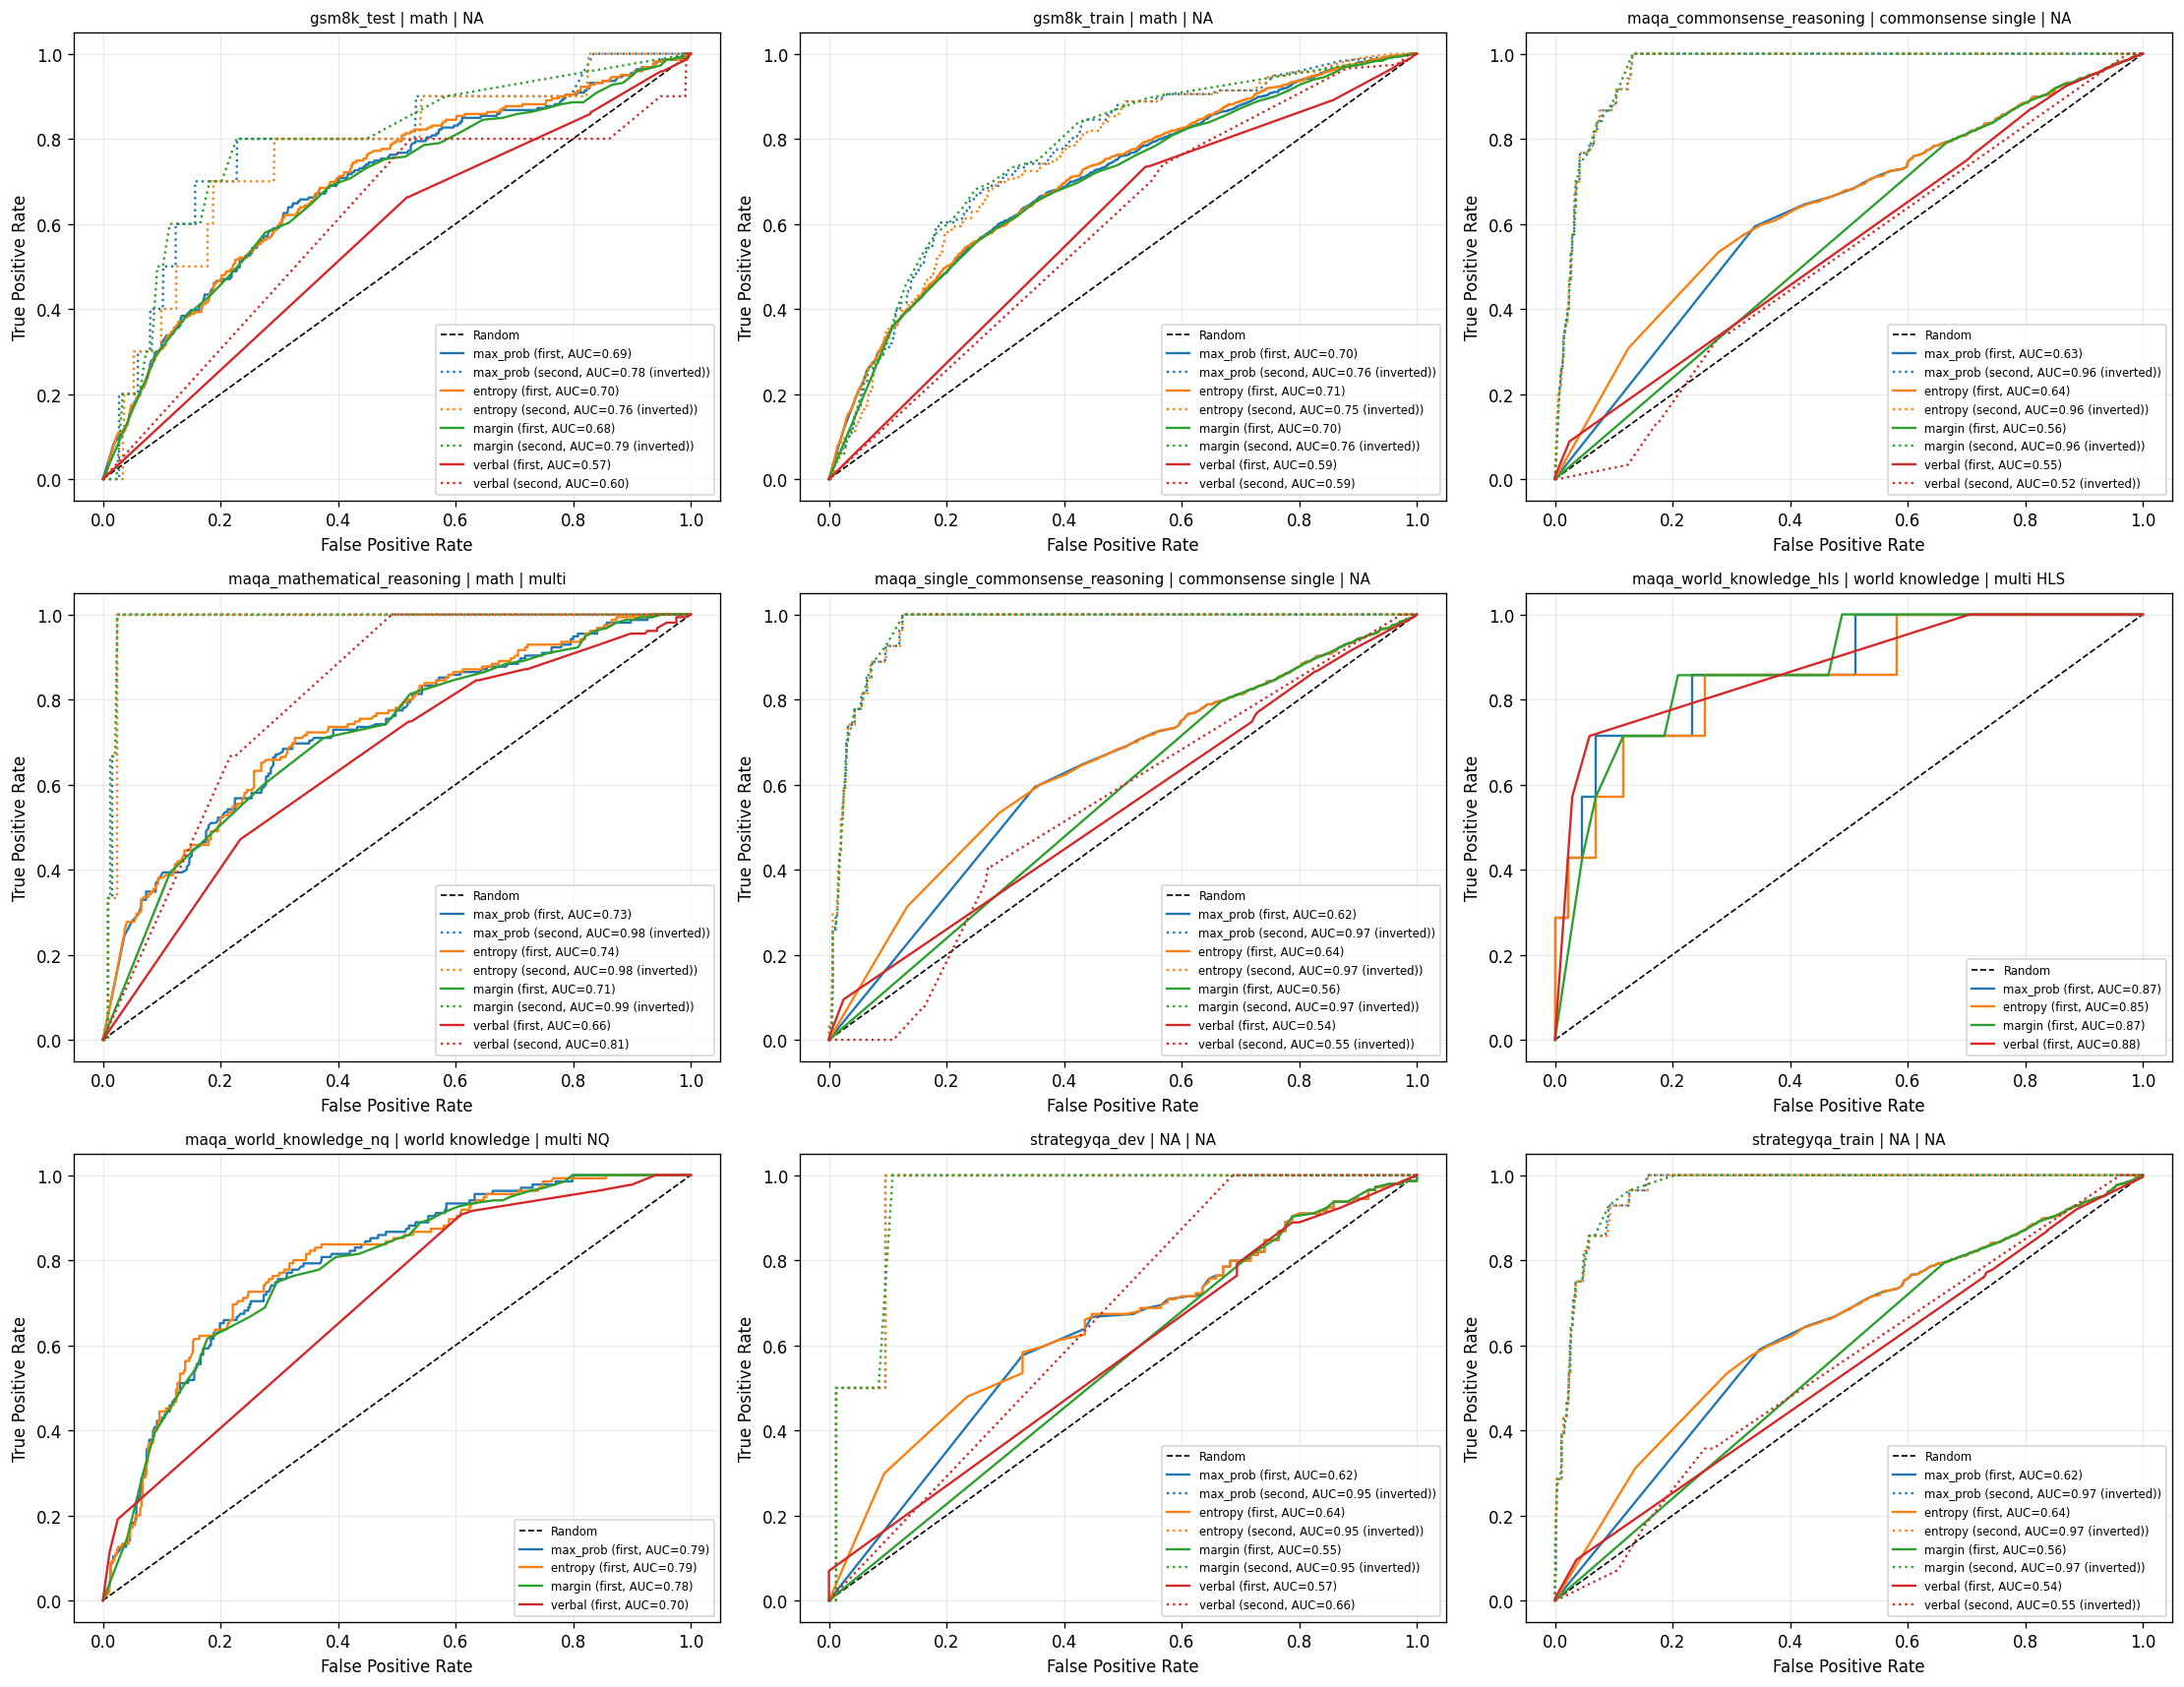

In [5]:
groups = list(iter_groups(df))
print("Number of subplots:", len(groups))

n = len(groups)
if n == 0:
    raise ValueError("No groups found to plot")

ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2 * ncols, 4.8 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax in axes_flat[n:]:
    ax.axis("off")

for i, ((dataset, categorie, subcategorie), g) in enumerate(groups):
    ax = axes_flat[i]
    title = f"{dataset} | {categorie} | {subcategorie}"
    ax.set_title(title, fontsize=9)
    ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True, alpha=0.25)

    for metric in METRICS:
        color = METRIC_COLORS.get(metric, None)
        for try_name, linestyle in [("first", "-"), ("second", ":")]:
            lbl_col = _label_col(try_name)
            sc_col = _score_col(try_name, metric)
            if lbl_col not in g.columns or sc_col not in g.columns:
                continue
            y_true = g[lbl_col].to_numpy(dtype=int)
            scores = _coerce_numeric(g[sc_col])
            roc_res = compute_roc(y_true, scores)
            if roc_res is None:
                continue
            fpr, tpr, roc_auc = roc_res
            inverted = False
            if roc_auc < 0.5:
                inv_scores = _invert_scores(scores)
                roc_res2 = compute_roc(y_true, inv_scores)
                if roc_res2 is not None:
                    fpr, tpr, roc_auc = roc_res2
                    inverted = True
            suffix = " (inverted)" if inverted else ""
            label = f"{metric} ({try_name}, AUC={roc_auc:.2f}{suffix})"
            ax.plot(fpr, tpr, linestyle=linestyle, color=color, lw=1.4, label=label)

    ax.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

## 2) Precision–Recall curves per (dataset, categorie, subcategorie)
Each subplot: random classifier baseline + 4 metrics (solid = first try, dotted = second try).

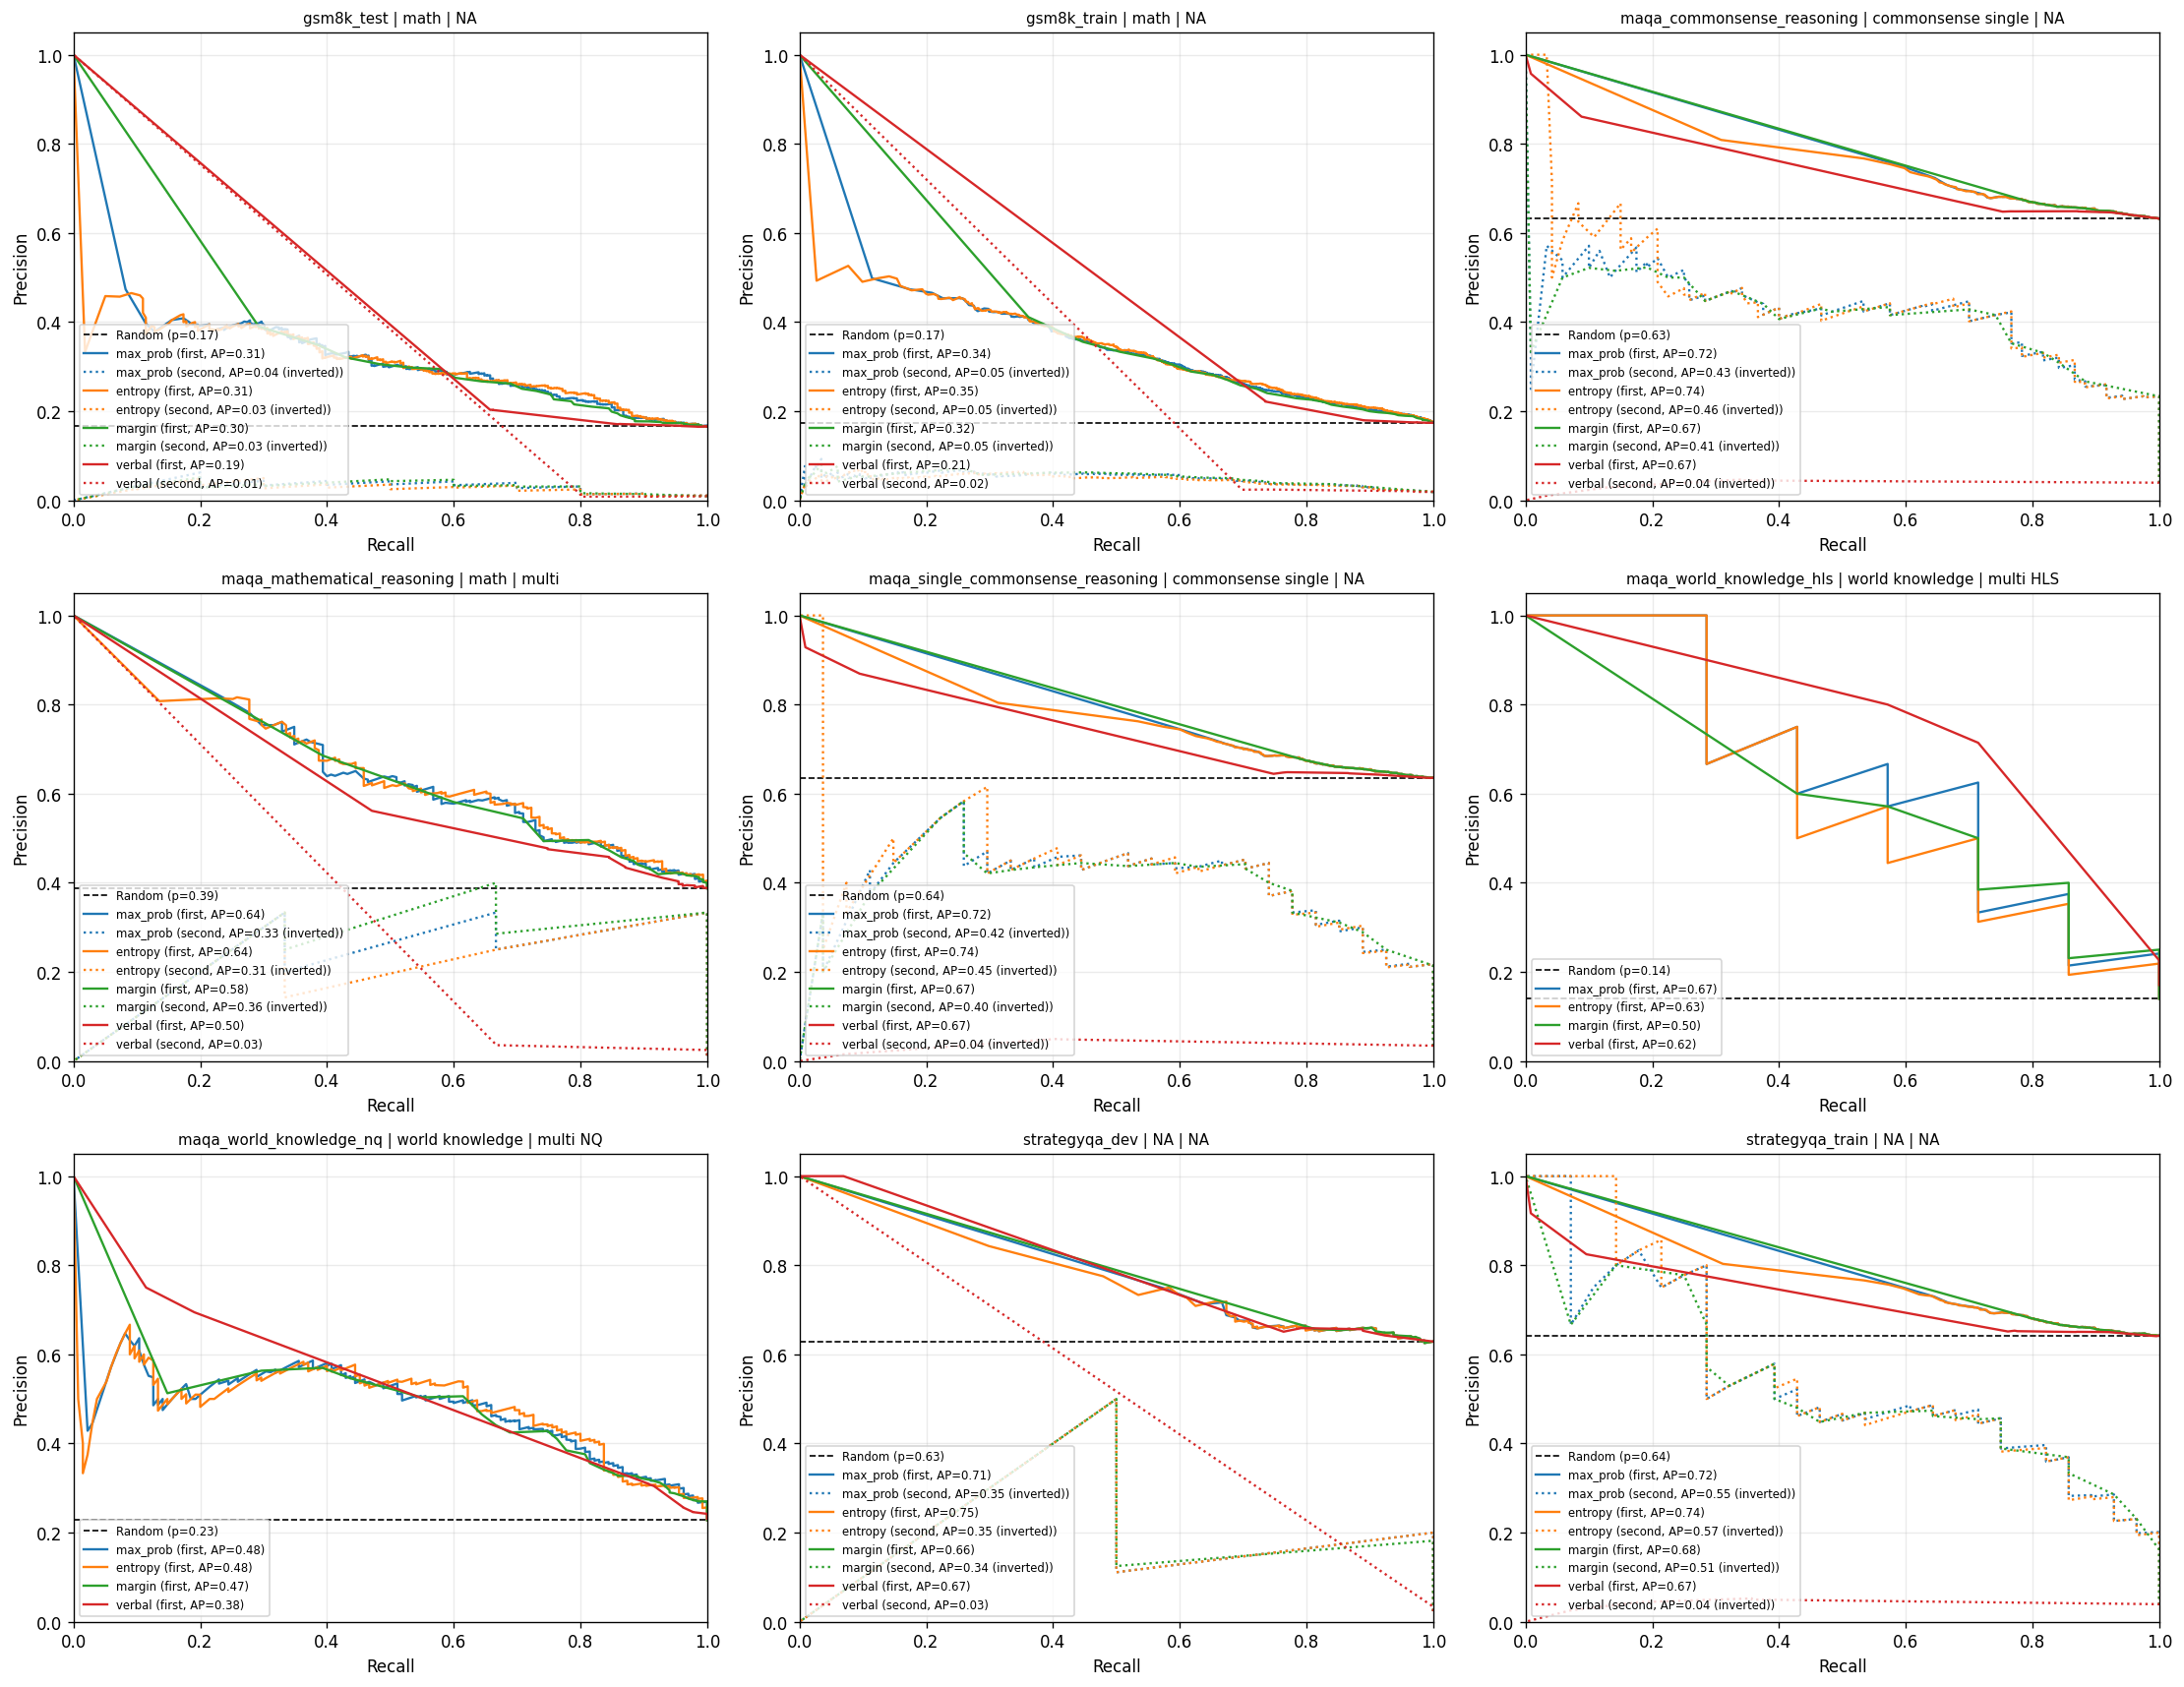

In [9]:
groups = list(iter_groups(df))
n = len(groups)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2 * ncols, 4.8 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax in axes_flat[n:]:
    ax.axis("off")

for i, ((dataset, categorie, subcategorie), g) in enumerate(groups):
    ax = axes_flat[i]
    title = f"{dataset} | {categorie} | {subcategorie}"
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True, alpha=0.25)

    # Random classifier PR baseline (single line to keep total = 9).
    base_rate = float(g.get("first_try_correct", pd.Series([0])).mean())
    ax.plot([0, 1], [base_rate, base_rate], "k--", lw=1.0, label=f"Random (p={base_rate:.2f})")

    for metric in METRICS:
        color = METRIC_COLORS.get(metric, None)
        for try_name, linestyle in [("first", "-"), ("second", ":")]:
            lbl_col = _label_col(try_name)
            sc_col = _score_col(try_name, metric)
            if lbl_col not in g.columns or sc_col not in g.columns:
                continue
            y_true = g[lbl_col].to_numpy(dtype=int)
            scores = _coerce_numeric(g[sc_col])

            # Apply the SAME inversion decision as ROC: invert when AUROC < 0.5.
            roc_res = compute_roc(y_true, scores)
            inverted = False
            pr_scores = scores
            if roc_res is not None:
                _fpr, _tpr, roc_auc = roc_res
                if roc_auc < 0.5:
                    pr_scores = _invert_scores(scores)
                    inverted = True

            pr_res = compute_pr(y_true, pr_scores)
            if pr_res is None:
                continue
            recall, precision, ap = pr_res
            suffix = " (inverted)" if inverted else ""
            label = f"{metric} ({try_name}, AP={ap:.2f}{suffix})"
            ax.plot(recall, precision, linestyle=linestyle, color=color, lw=1.4, label=label)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, loc="lower left")

plt.tight_layout()
plt.show()

## 3) Averaged curves (4 panels)
Panels:
1. Average ROC across all groups
2. Average PR across all groups
3. Average ROC excluding MAQA multi-answer datasets (`'maqa'` and not `'single'`)
4. Average PR excluding MAQA multi-answer datasets (`'maqa'` and not `'single'`)

In [11]:
def average_roc_curves(frame: pd.DataFrame) -> dict[tuple[str, str], tuple[np.ndarray, np.ndarray, float]]:
    """Return averaged ROC curves keyed by (try_name, metric)."""
    fpr_grid = np.linspace(0.0, 1.0, 201)
    acc: dict[tuple[str, str], list[np.ndarray]] = {}
    for (_key, g) in iter_groups(frame):
        for metric in METRICS:
            for try_name in ("first", "second"):
                lbl_col = _label_col(try_name)
                sc_col = _score_col(try_name, metric)
                if lbl_col not in g.columns or sc_col not in g.columns:
                    continue
                y_true = g[lbl_col].to_numpy(dtype=int)
                scores = _coerce_numeric(g[sc_col])
                roc_res = compute_roc(y_true, scores)
                if roc_res is None:
                    continue
                fpr, tpr, roc_auc = roc_res
                if roc_auc < 0.5:
                    roc_res2 = compute_roc(y_true, _invert_scores(scores))
                    if roc_res2 is not None:
                        fpr, tpr, roc_auc = roc_res2
                # Ensure endpoints for stable interpolation
                if fpr[0] > 0:
                    fpr = np.concatenate([[0.0], fpr])
                    tpr = np.concatenate([[0.0], tpr])
                if fpr[-1] < 1:
                    fpr = np.concatenate([fpr, [1.0]])
                    tpr = np.concatenate([tpr, [1.0]])
                tpr_i = np.interp(fpr_grid, fpr, tpr)
                acc.setdefault((try_name, metric), []).append(tpr_i)
    out: dict[tuple[str, str], tuple[np.ndarray, np.ndarray, float]] = {}
    for k, tprs in acc.items():
        mean_tpr = np.mean(np.vstack(tprs), axis=0)
        out[k] = (fpr_grid, mean_tpr, float(auc(fpr_grid, mean_tpr)))
    return out


def average_pr_curves(frame: pd.DataFrame) -> dict[tuple[str, str], tuple[np.ndarray, np.ndarray, float, bool]]:
    """Return averaged PR curves keyed by (try_name, metric).
    
    Uses the same inversion decision as ROC: per-group invert scores when AUROC < 0.5.
    Returns (recall_grid, mean_precision, mean_ap, inverted_any).
    """
    recall_grid = np.linspace(0.0, 1.0, 201)
    acc: dict[tuple[str, str], list[np.ndarray]] = {}
    aps: dict[tuple[str, str], list[float]] = {}
    inverted_any: dict[tuple[str, str], bool] = {}
    for (_key, g) in iter_groups(frame):
        for metric in METRICS:
            for try_name in ("first", "second"):
                lbl_col = _label_col(try_name)
                sc_col = _score_col(try_name, metric)
                if lbl_col not in g.columns or sc_col not in g.columns:
                    continue
                y_true = g[lbl_col].to_numpy(dtype=int)
                scores = _coerce_numeric(g[sc_col])

                # Same inversion decision as ROC, per group.
                roc_res = compute_roc(y_true, scores)
                use_scores = scores
                inverted = False
                if roc_res is not None:
                    _fpr, _tpr, roc_auc = roc_res
                    if roc_auc < 0.5:
                        use_scores = _invert_scores(scores)
                        inverted = True

                pr_res = compute_pr(y_true, use_scores)
                if pr_res is None:
                    continue
                recall, precision, ap = pr_res
                # precision_recall_curve returns recall descending; make it ascending for interpolation.
                recall = recall[::-1]
                precision = precision[::-1]
                if recall[0] > 0:
                    recall = np.concatenate([[0.0], recall])
                    precision = np.concatenate([[precision[0]], precision])
                if recall[-1] < 1:
                    recall = np.concatenate([recall, [1.0]])
                    precision = np.concatenate([precision, [precision[-1]]])
                prec_i = np.interp(recall_grid, recall, precision)
                key = (try_name, metric)
                acc.setdefault(key, []).append(prec_i)
                aps.setdefault(key, []).append(ap)
                inverted_any[key] = inverted_any.get(key, False) or inverted
    out: dict[tuple[str, str], tuple[np.ndarray, np.ndarray, float, bool]] = {}
    for k, precs in acc.items():
        mean_prec = np.mean(np.vstack(precs), axis=0)
        mean_ap = float(np.mean(aps.get(k, [np.nan])))
        out[k] = (recall_grid, mean_prec, mean_ap, bool(inverted_any.get(k, False)))
    return out


def average_pr_baseline(frame: pd.DataFrame) -> float:
    """Single PR baseline line (to keep total lines = 9). Uses mean first-try prevalence across groups."""
    rates = []
    for (_key, g) in iter_groups(frame):
        if "first_try_correct" in g.columns:
            rates.append(float(g["first_try_correct"].mean()))
    return float(np.mean(rates)) if rates else 0.0

Rows (all): 22762 Rows (single subset): 13286


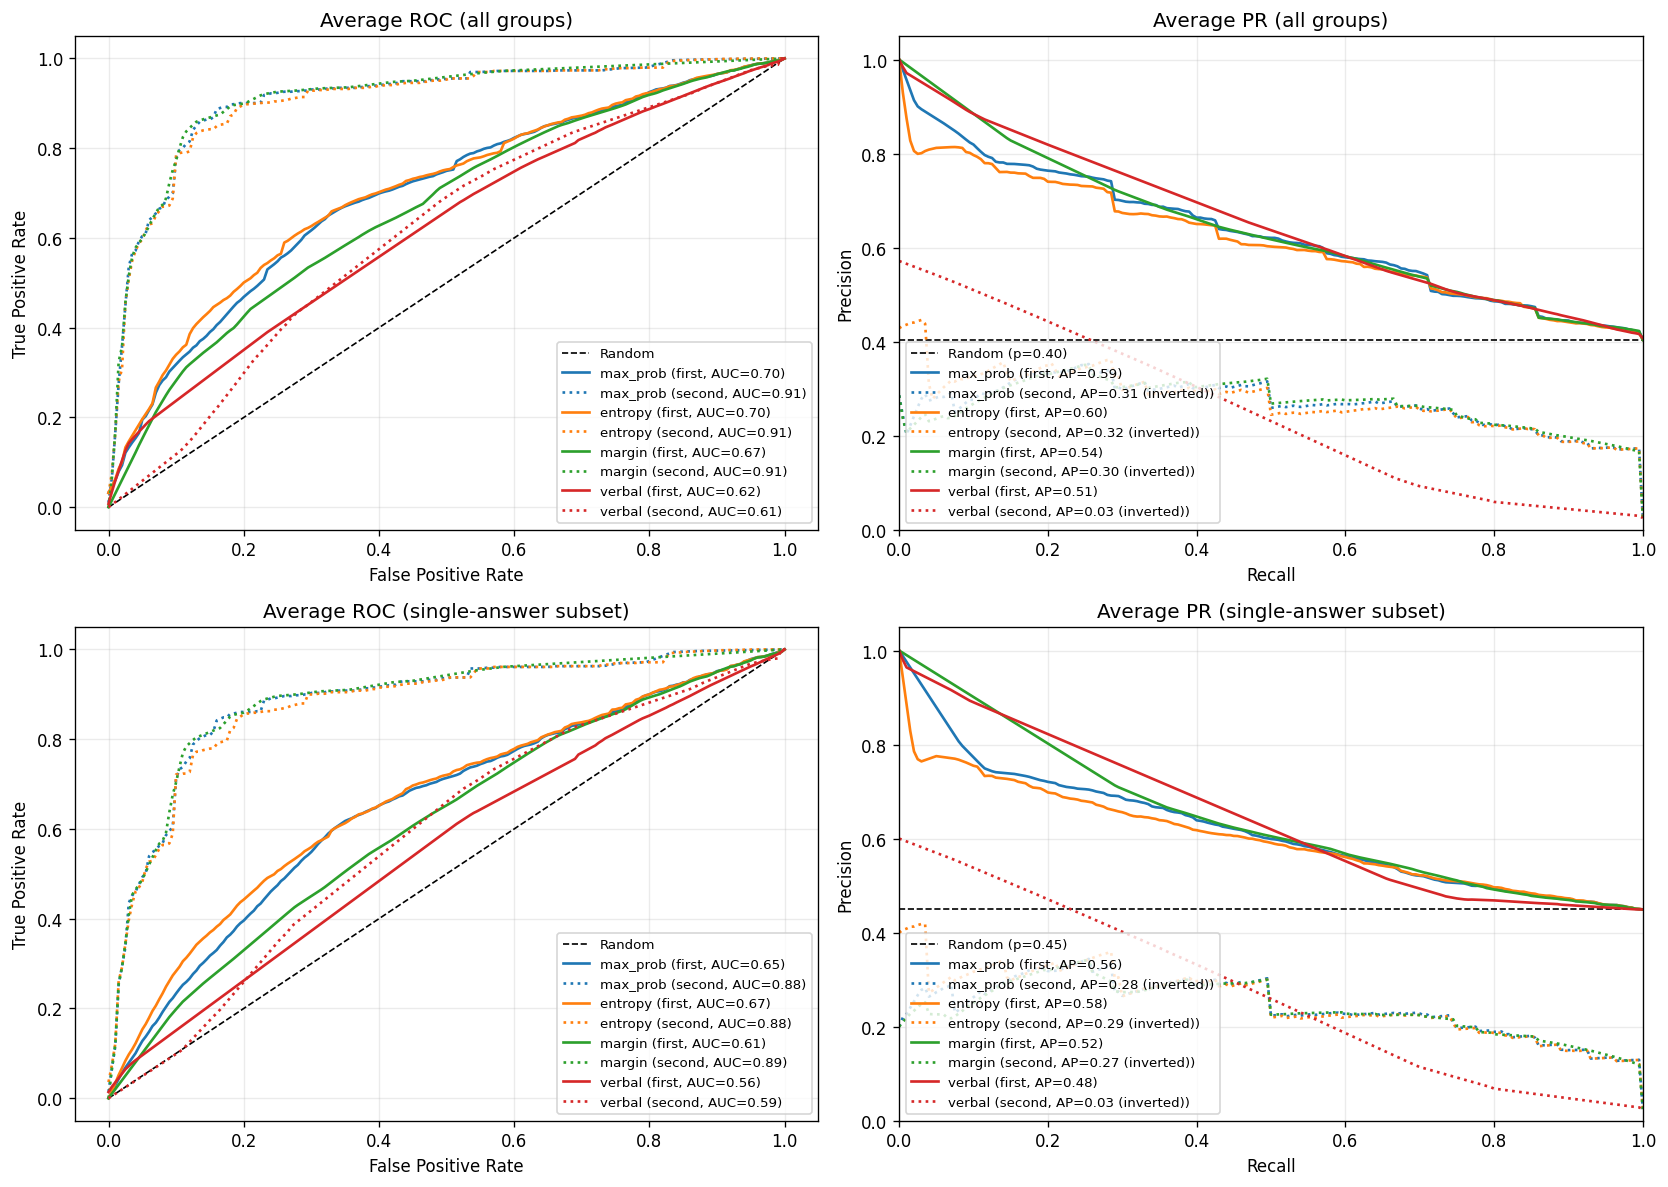

In [12]:
def plot_average_panels(frame_all: pd.DataFrame, frame_single: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax_roc_all, ax_pr_all = axes[0, 0], axes[0, 1]
    ax_roc_single, ax_pr_single = axes[1, 0], axes[1, 1]

    def _plot_roc(ax, frame, title):
        curves = average_roc_curves(frame)
        ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="Random")
        for metric in METRICS:
            color = METRIC_COLORS[metric]
            for try_name, linestyle in [("first", "-"), ("second", ":")]:
                key = (try_name, metric)
                if key not in curves:
                    continue
                x, y, a_ = curves[key]
                ax.plot(x, y, linestyle=linestyle, color=color, lw=1.6, label=f"{metric} ({try_name}, AUC={a_:.2f})")
        ax.set_title(title)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="lower right")

    def _plot_pr(ax, frame, title):
        curves = average_pr_curves(frame)
        baseline = average_pr_baseline(frame)
        ax.plot([0, 1], [baseline, baseline], "k--", lw=1.0, label=f"Random (p={baseline:.2f})")
        for metric in METRICS:
            color = METRIC_COLORS[metric]
            for try_name, linestyle in [("first", "-"), ("second", ":")]:
                key = (try_name, metric)
                if key not in curves:
                    continue
                val = curves[key]
                if isinstance(val, tuple) and len(val) == 4:
                    x, y, ap, inverted_any = val
                elif isinstance(val, tuple) and len(val) == 3:
                    x, y, ap = val
                    inverted_any = False
                else:
                    raise ValueError(f"Unexpected average_pr_curves value for {key}: {type(val)} {val}")
                suffix = " (inverted)" if inverted_any else ""
                ax.plot(x, y, linestyle=linestyle, color=color, lw=1.6, label=f"{metric} ({try_name}, AP={ap:.2f}{suffix})")
        ax.set_title(title)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="lower left")

    _plot_roc(ax_roc_all, frame_all, "Average ROC (all groups)")
    _plot_pr(ax_pr_all, frame_all, "Average PR (all groups)")
    _plot_roc(ax_roc_single, frame_single, "Average ROC (single-answer subset)")
    _plot_pr(ax_pr_single, frame_single, "Average PR (single-answer subset)")

    plt.tight_layout()
    plt.show()


mask_single = (~df["dataset"].str.contains("maqa", case=False, na=False)) | (df["dataset"].str.contains("single", case=False, na=False))
df_single = df[mask_single].copy()
print("Rows (all):", len(df), "Rows (single subset):", len(df_single))

plot_average_panels(df, df_single)

## 4) Two-try combined evaluation
In this section we treat a question as **correct within two tries** if `first_try_correct == 1` **or** `second_try_correct == 1`.
We plot:
- ROC + Precision–Recall curves for this *combined* outcome (per group and averaged; all vs. single-answer subset).
- Percent answered correctly on the **first try** vs on the **second try** (where “second try correct” means *first was wrong and second was correct*), per group and averaged (all vs. single-answer subset).

In [13]:
def _combined_correct(frame: pd.DataFrame) -> np.ndarray:
    if "first_try_correct" not in frame.columns or "second_try_correct" not in frame.columns:
        raise KeyError("Need first_try_correct and second_try_correct for combined evaluation")
    first = frame["first_try_correct"].to_numpy(dtype=int)
    second = frame["second_try_correct"].to_numpy(dtype=int)
    return ((first == 1) | (second == 1)).astype(int)


def _second_try_gain(frame: pd.DataFrame) -> np.ndarray:
    """1 if wrong on first try but correct on second try."""
    first = frame["first_try_correct"].to_numpy(dtype=int)
    second = frame["second_try_correct"].to_numpy(dtype=int)
    return ((first == 0) & (second == 1)).astype(int)


def _combined_score(frame: pd.DataFrame, metric: str) -> np.ndarray:
    """Combine first+second try scores into a single score per row (best of two)."""
    c1 = _score_col("first", metric)
    c2 = _score_col("second", metric)
    if c1 not in frame.columns:
        raise KeyError(f"Missing score column: {c1}")
    s1 = _coerce_numeric(frame[c1])
    if c2 in frame.columns:
        s2 = _coerce_numeric(frame[c2])
        return np.nanmax(np.vstack([s1, s2]), axis=0)
    return s1


def compute_roc_with_inversion_decision(y_true: np.ndarray, scores: np.ndarray) -> tuple[np.ndarray, np.ndarray, float, bool] | None:
    """Return (fpr, tpr, auc, inverted) using the same inversion rule as earlier: invert if AUROC < 0.5."""
    roc_res = compute_roc(y_true, scores)
    if roc_res is None:
        return None
    fpr, tpr, roc_auc = roc_res
    inverted = False
    if roc_auc < 0.5:
        inv_scores = _invert_scores(scores)
        roc_res2 = compute_roc(y_true, inv_scores)
        if roc_res2 is not None:
            fpr, tpr, roc_auc = roc_res2
            inverted = True
    return fpr, tpr, roc_auc, inverted


def compute_pr_with_optional_inversion(y_true: np.ndarray, scores: np.ndarray, invert: bool) -> tuple[np.ndarray, np.ndarray, float] | None:
    """Compute PR, optionally inverting scores first."""
    use_scores = _invert_scores(scores) if invert else scores
    return compute_pr(y_true, use_scores)

### 4.1) ROC curves for combined (≤2 tries) correctness
Each subplot: random classifier + 4 metrics (combined score = best of first/second).
If AUROC < 0.5, the curve is inverted and marked in the legend.

Number of subplots: 9


/tmp/ipykernel_26033/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_26033/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_26033/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)


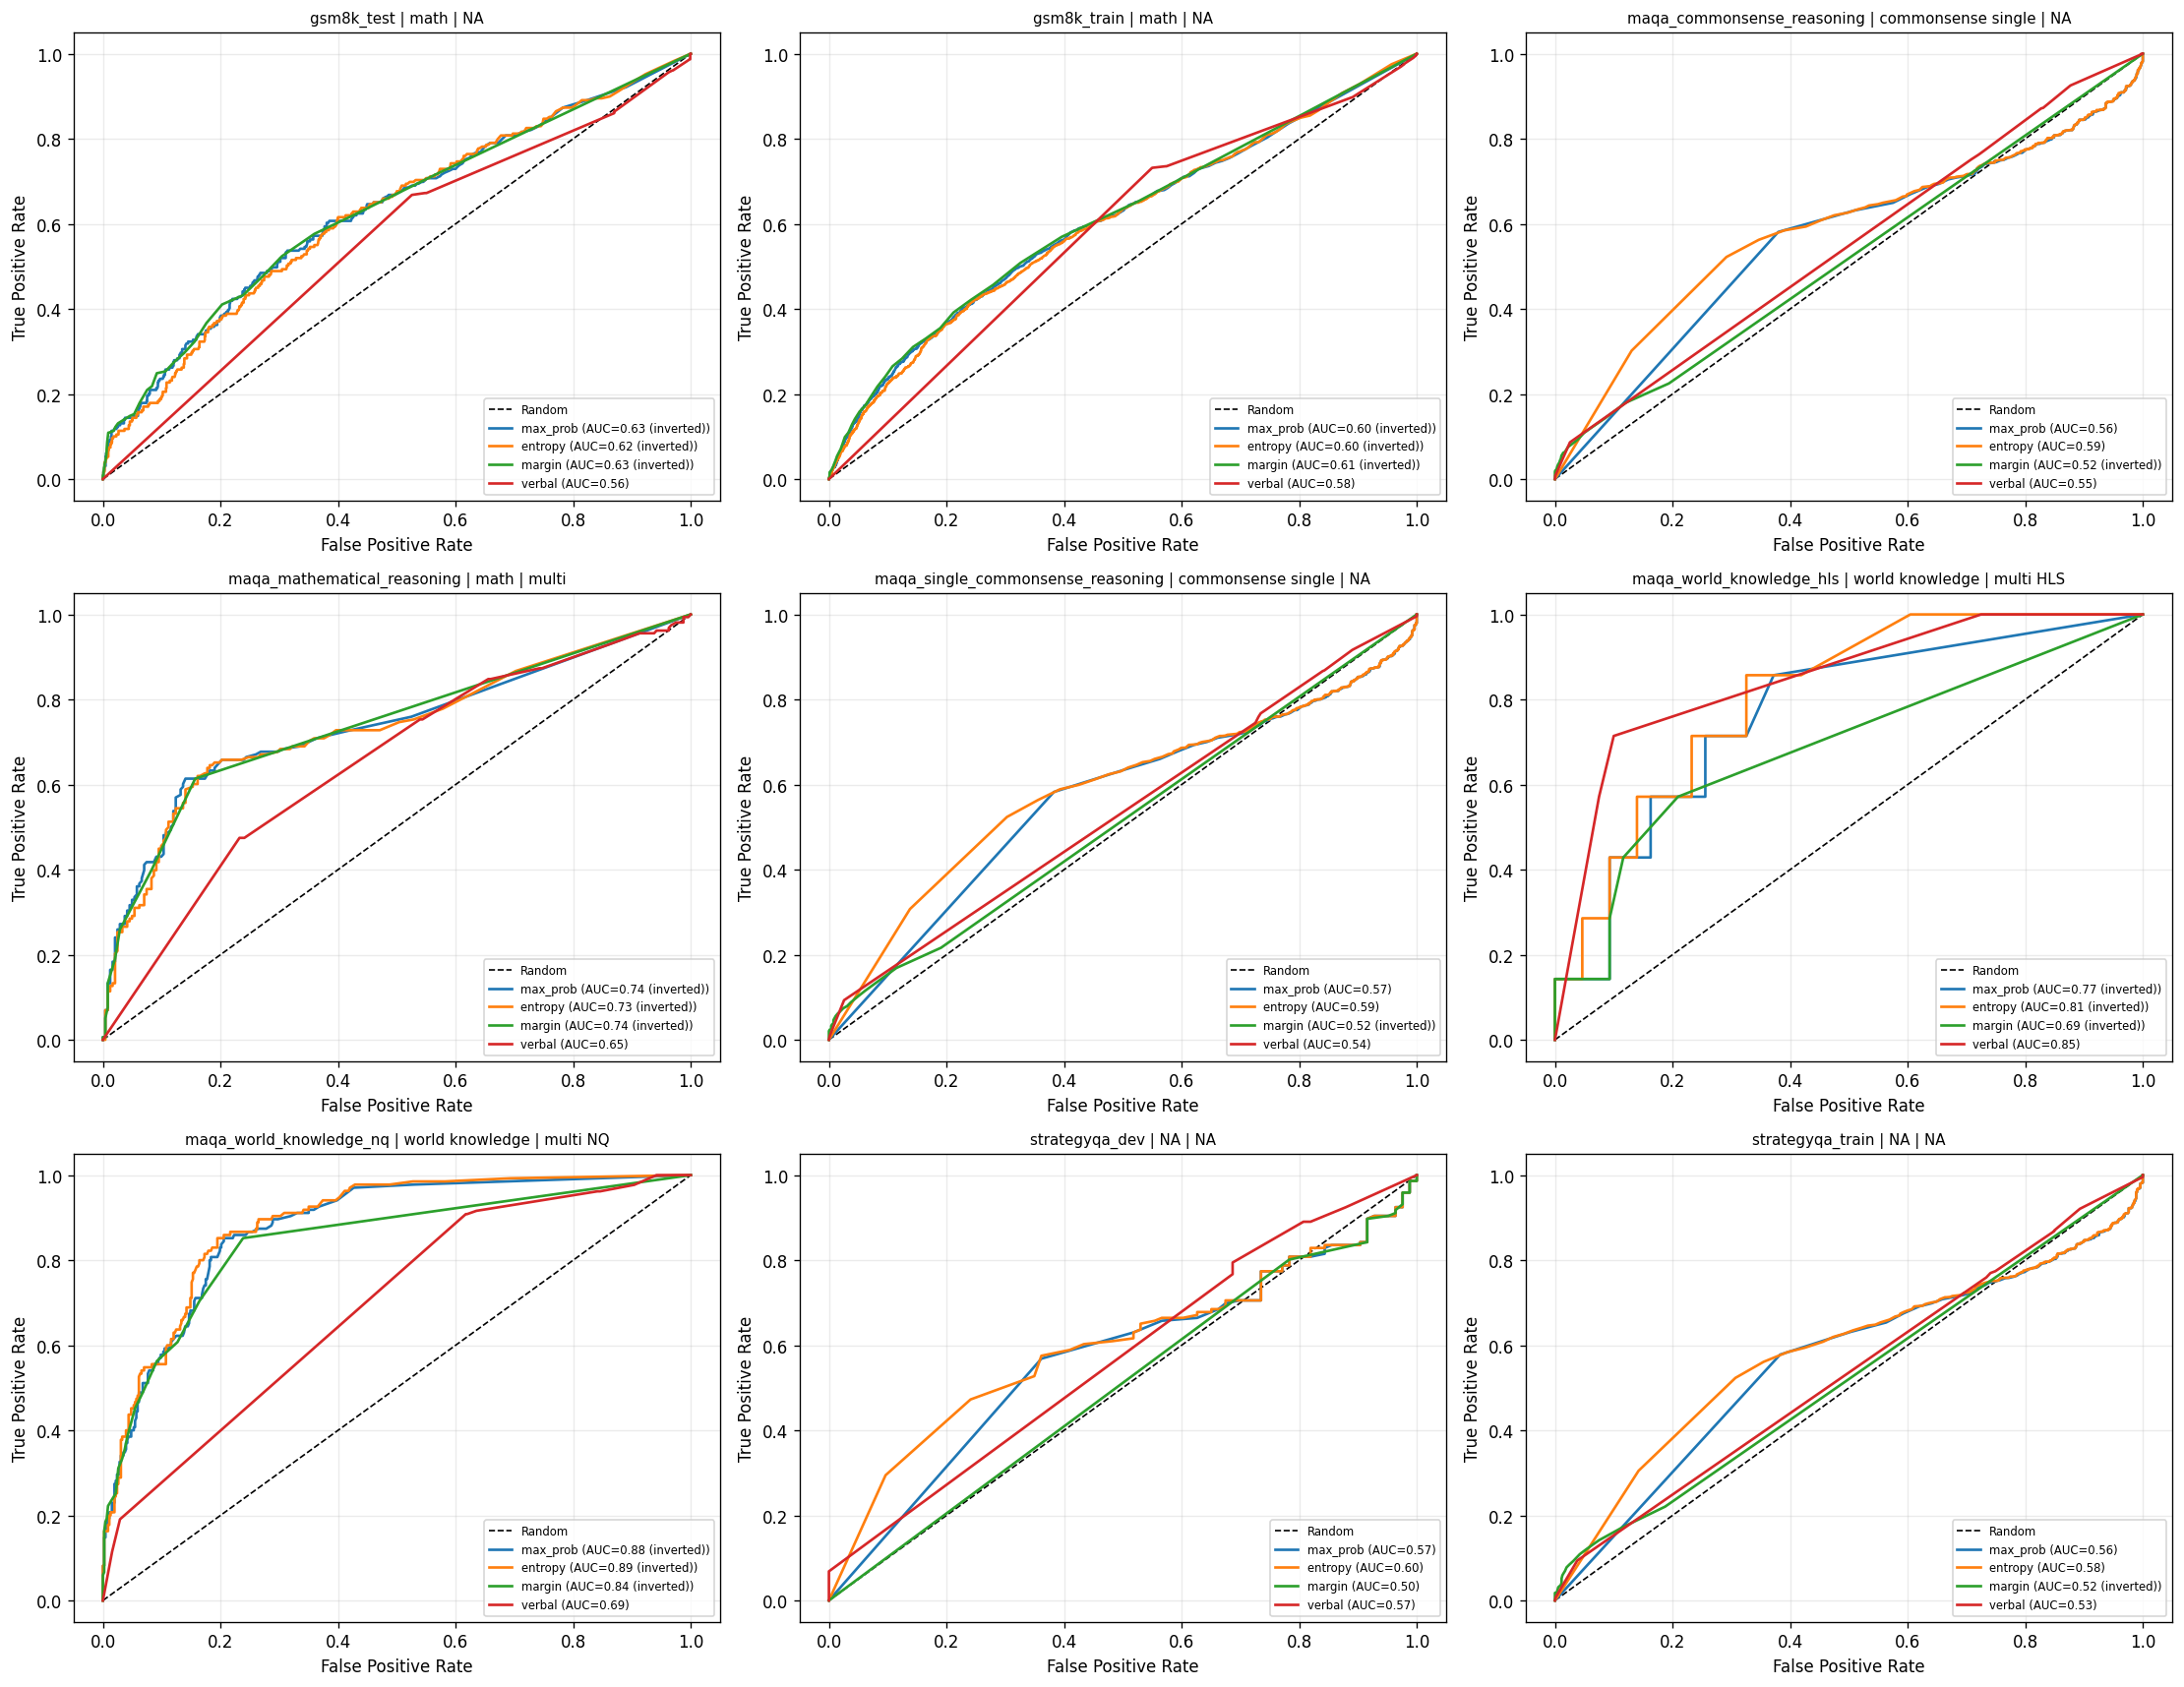

In [14]:
groups = list(iter_groups(df))
print("Number of subplots:", len(groups))

n = len(groups)
if n == 0:
    raise ValueError("No groups found to plot")

ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2 * ncols, 4.8 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax in axes_flat[n:]:
    ax.axis("off")

for i, ((dataset, categorie, subcategorie), g) in enumerate(groups):
    ax = axes_flat[i]
    title = f"{dataset} | {categorie} | {subcategorie}"
    ax.set_title(title, fontsize=9)
    ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True, alpha=0.25)

    y_true = _combined_correct(g)
    for metric in METRICS:
        color = METRIC_COLORS.get(metric, None)
        try:
            scores = _combined_score(g, metric)
        except KeyError:
            continue
        roc_res = compute_roc_with_inversion_decision(y_true, scores)
        if roc_res is None:
            continue
        fpr, tpr, roc_auc, inverted = roc_res
        suffix = " (inverted)" if inverted else ""
        ax.plot(fpr, tpr, color=color, lw=1.6, label=f"{metric} (AUC={roc_auc:.2f}{suffix})")

    ax.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

### 4.2) Precision–Recall curves for combined (≤2 tries) correctness
Each subplot: baseline prevalence + 4 metrics (combined score = best of first/second).
Uses the same inversion decision as ROC (invert PR scores if AUROC < 0.5).

/tmp/ipykernel_26033/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_26033/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_26033/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)


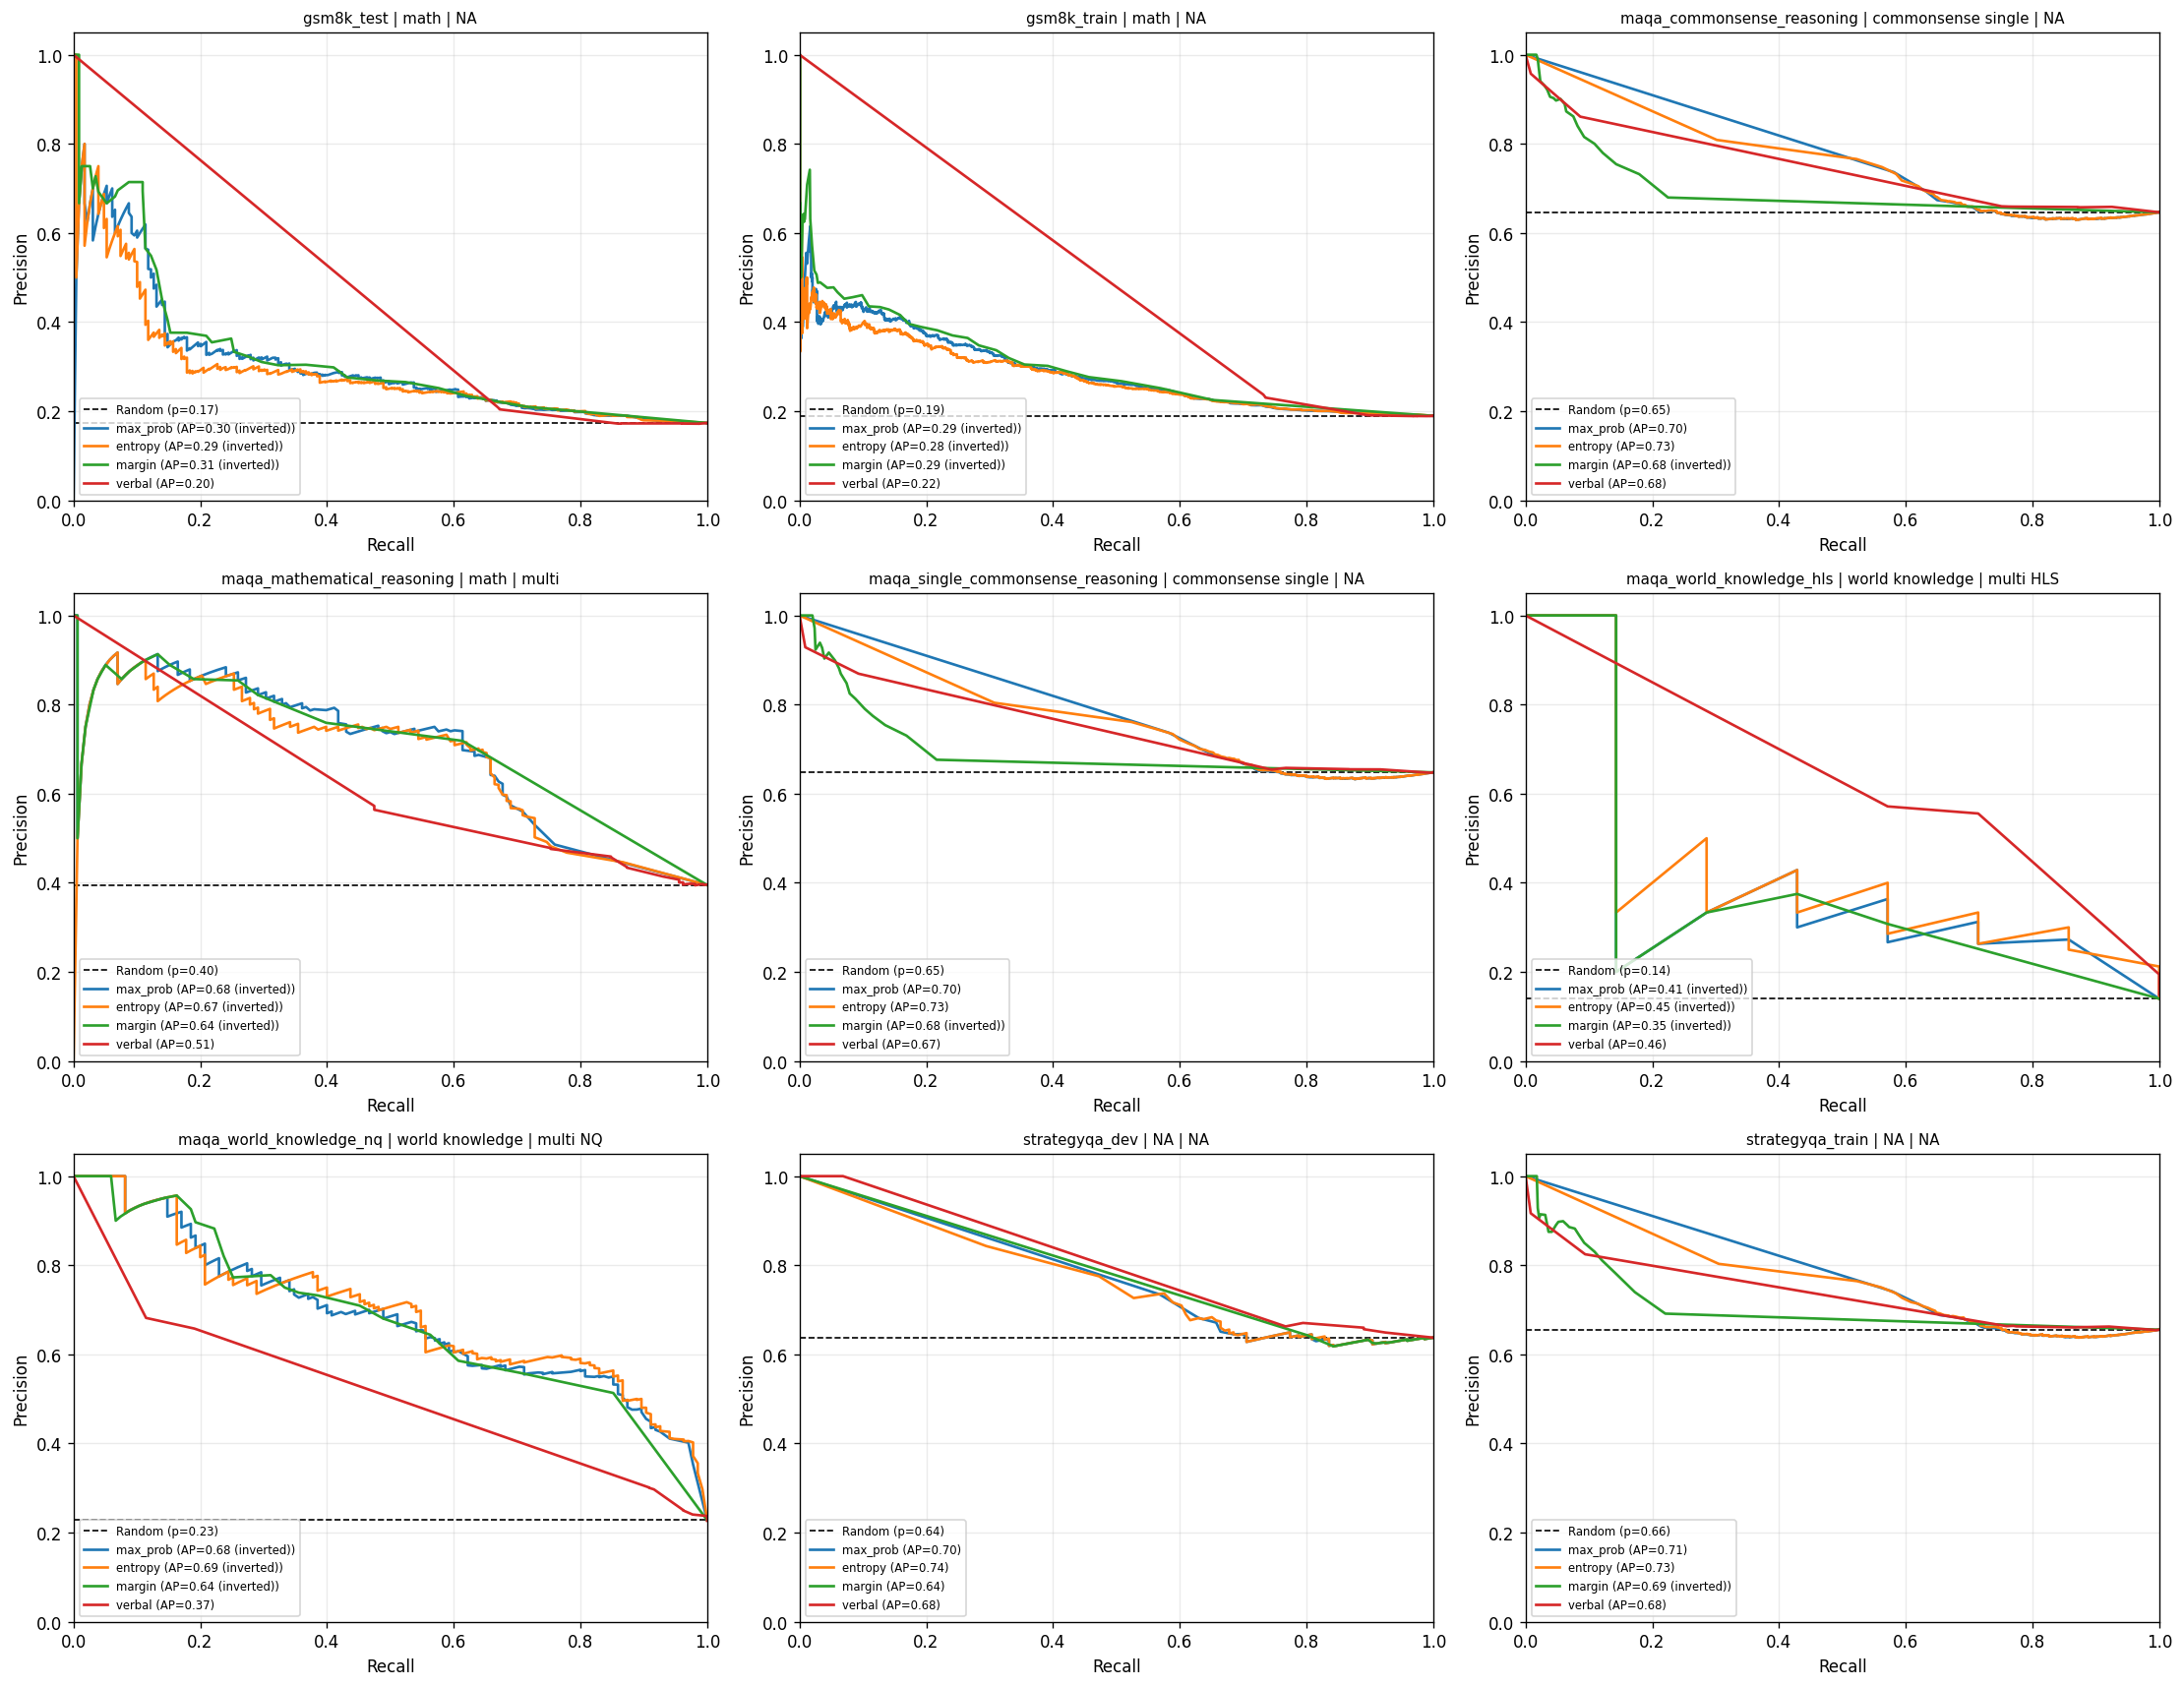

In [15]:
groups = list(iter_groups(df))
n = len(groups)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2 * ncols, 4.8 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax in axes_flat[n:]:
    ax.axis("off")

for i, ((dataset, categorie, subcategorie), g) in enumerate(groups):
    ax = axes_flat[i]
    title = f"{dataset} | {categorie} | {subcategorie}"
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True, alpha=0.25)

    y_true = _combined_correct(g)
    base_rate = float(np.mean(y_true)) if y_true.size else 0.0
    ax.plot([0, 1], [base_rate, base_rate], "k--", lw=1.0, label=f"Random (p={base_rate:.2f})")

    for metric in METRICS:
        color = METRIC_COLORS.get(metric, None)
        try:
            scores = _combined_score(g, metric)
        except KeyError:
            continue
        roc_res = compute_roc_with_inversion_decision(y_true, scores)
        if roc_res is None:
            continue
        _fpr, _tpr, _roc_auc, inverted = roc_res
        pr_res = compute_pr_with_optional_inversion(y_true, scores, invert=inverted)
        if pr_res is None:
            continue
        recall, precision, ap = pr_res
        suffix = " (inverted)" if inverted else ""
        ax.plot(recall, precision, color=color, lw=1.6, label=f"{metric} (AP={ap:.2f}{suffix})")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, loc="lower left")

plt.tight_layout()
plt.show()

### 4.3) Averaged combined curves (4 panels)
Panels: ROC/PR averaged across groups for (1) all data and (2) single-answer subset (excluding MAQA multi-answer datasets: `maqa` and not `single`).

Rows (all): 22762 Rows (single subset): 13286


/tmp/ipykernel_26033/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_26033/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_26033/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_26033/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_26033/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)
/tmp/ipykernel_26033/2228106794.py:25: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.vstack([s1, s2]), axis=0)


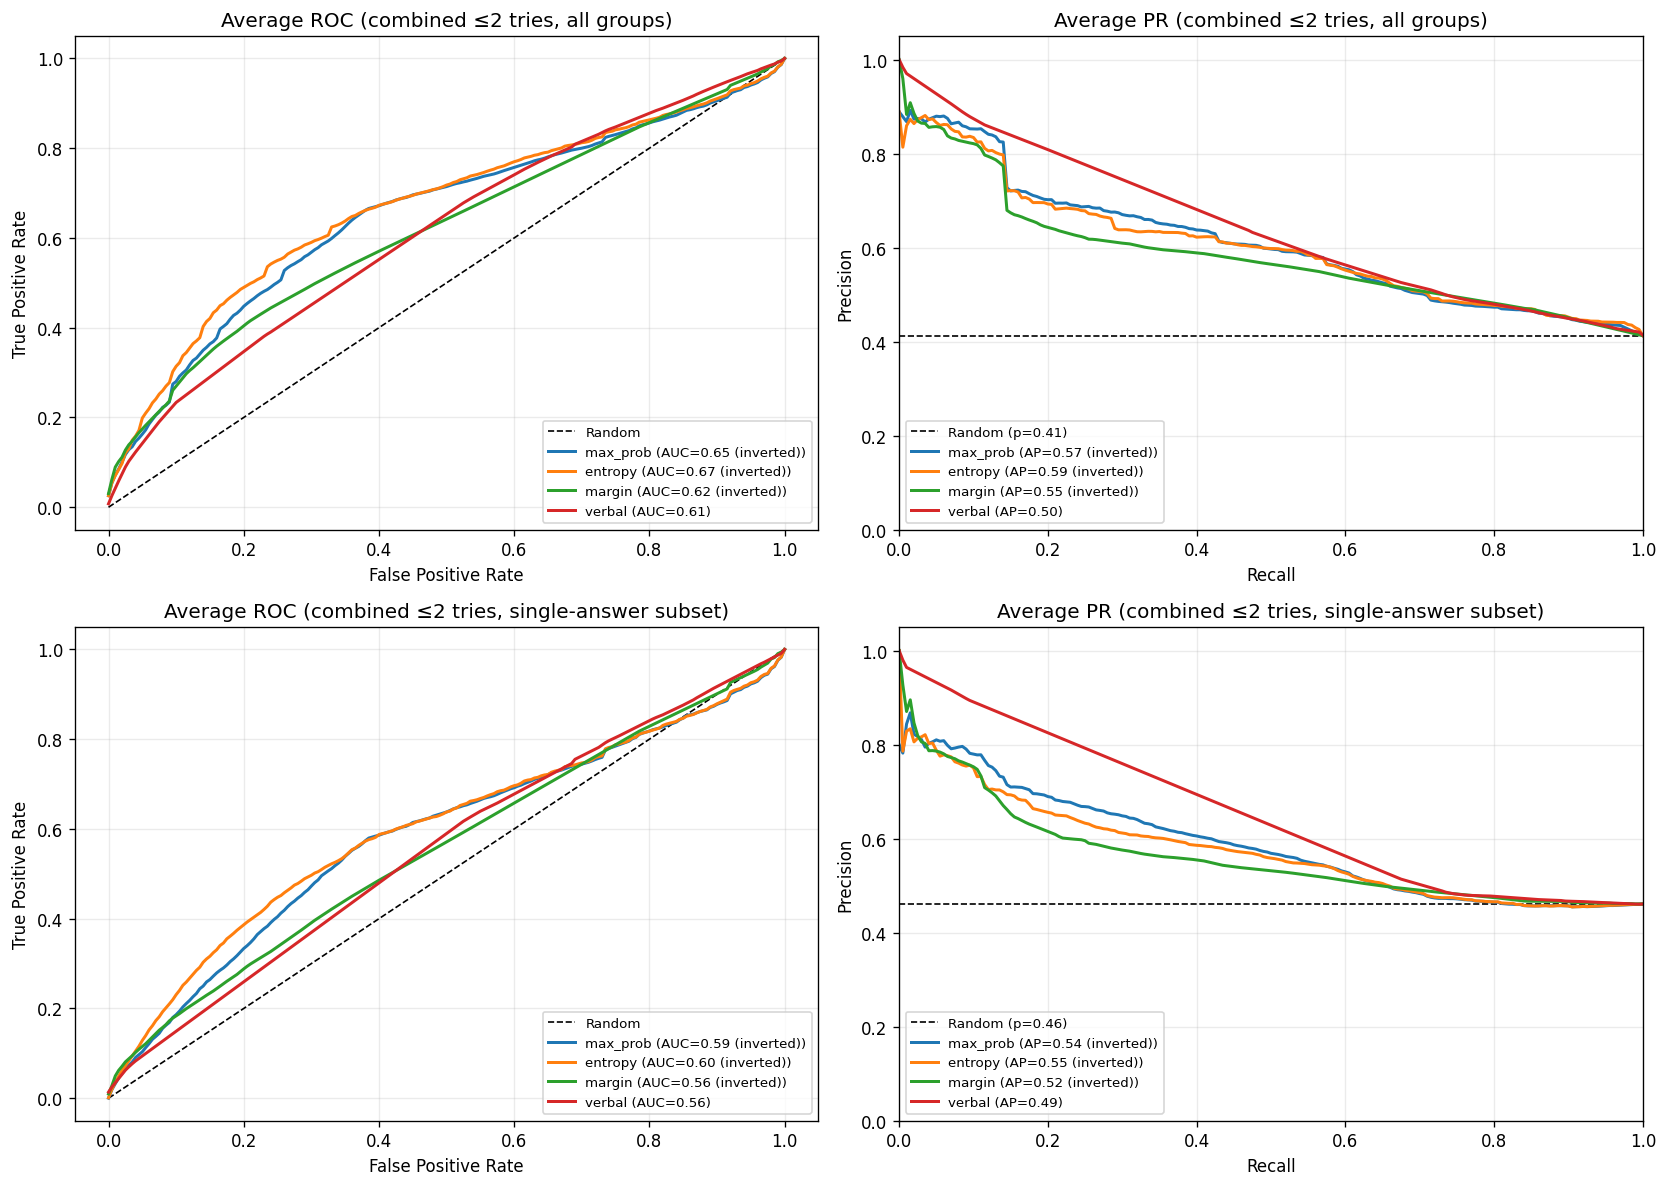

In [16]:
def average_roc_curves_combined(frame: pd.DataFrame) -> dict[str, tuple[np.ndarray, np.ndarray, float, bool]]:
    """Averaged ROC curves for combined outcome, keyed by metric.
    Returns (fpr_grid, mean_tpr, mean_auc, inverted_any).
    """
    fpr_grid = np.linspace(0.0, 1.0, 201)
    acc: dict[str, list[np.ndarray]] = {}
    aucs: dict[str, list[float]] = {}
    inverted_any: dict[str, bool] = {}
    for (_key, g) in iter_groups(frame):
        y_true = _combined_correct(g)
        for metric in METRICS:
            try:
                scores = _combined_score(g, metric)
            except KeyError:
                continue
            roc_res = compute_roc_with_inversion_decision(y_true, scores)
            if roc_res is None:
                continue
            fpr, tpr, roc_auc, inverted = roc_res
            if fpr[0] > 0:
                fpr = np.concatenate([[0.0], fpr])
                tpr = np.concatenate([[0.0], tpr])
            if fpr[-1] < 1:
                fpr = np.concatenate([fpr, [1.0]])
                tpr = np.concatenate([tpr, [1.0]])
            tpr_i = np.interp(fpr_grid, fpr, tpr)
            acc.setdefault(metric, []).append(tpr_i)
            aucs.setdefault(metric, []).append(float(roc_auc))
            inverted_any[metric] = inverted_any.get(metric, False) or inverted
    out: dict[str, tuple[np.ndarray, np.ndarray, float, bool]] = {}
    for metric, tprs in acc.items():
        mean_tpr = np.mean(np.vstack(tprs), axis=0)
        mean_auc = float(np.mean(aucs.get(metric, [np.nan])))
        out[metric] = (fpr_grid, mean_tpr, mean_auc, bool(inverted_any.get(metric, False)))
    return out


def average_pr_curves_combined(frame: pd.DataFrame) -> dict[str, tuple[np.ndarray, np.ndarray, float, bool]]:
    """Averaged PR curves for combined outcome, keyed by metric.
    Returns (recall_grid, mean_precision, mean_ap, inverted_any).
    """
    recall_grid = np.linspace(0.0, 1.0, 201)
    acc: dict[str, list[np.ndarray]] = {}
    aps: dict[str, list[float]] = {}
    inverted_any: dict[str, bool] = {}
    for (_key, g) in iter_groups(frame):
        y_true = _combined_correct(g)
        for metric in METRICS:
            try:
                scores = _combined_score(g, metric)
            except KeyError:
                continue
            roc_res = compute_roc_with_inversion_decision(y_true, scores)
            if roc_res is None:
                continue
            _fpr, _tpr, _roc_auc, inverted = roc_res
            pr_res = compute_pr_with_optional_inversion(y_true, scores, invert=inverted)
            if pr_res is None:
                continue
            recall, precision, ap = pr_res
            recall = recall[::-1]
            precision = precision[::-1]
            if recall[0] > 0:
                recall = np.concatenate([[0.0], recall])
                precision = np.concatenate([[precision[0]], precision])
            if recall[-1] < 1:
                recall = np.concatenate([recall, [1.0]])
                precision = np.concatenate([precision, [precision[-1]]])
            prec_i = np.interp(recall_grid, recall, precision)
            acc.setdefault(metric, []).append(prec_i)
            aps.setdefault(metric, []).append(float(ap))
            inverted_any[metric] = inverted_any.get(metric, False) or inverted
    out: dict[str, tuple[np.ndarray, np.ndarray, float, bool]] = {}
    for metric, precs in acc.items():
        mean_prec = np.mean(np.vstack(precs), axis=0)
        mean_ap = float(np.mean(aps.get(metric, [np.nan])))
        out[metric] = (recall_grid, mean_prec, mean_ap, bool(inverted_any.get(metric, False)))
    return out


def average_pr_baseline_combined(frame: pd.DataFrame) -> float:
    rates = []
    for (_key, g) in iter_groups(frame):
        y_true = _combined_correct(g)
        if y_true.size:
            rates.append(float(np.mean(y_true)))
    return float(np.mean(rates)) if rates else 0.0


def plot_average_panels_combined(frame_all: pd.DataFrame, frame_single: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax_roc_all, ax_pr_all = axes[0, 0], axes[0, 1]
    ax_roc_single, ax_pr_single = axes[1, 0], axes[1, 1]

    def _plot_roc(ax, frame, title):
        curves = average_roc_curves_combined(frame)
        ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="Random")
        for metric in METRICS:
            if metric not in curves:
                continue
            color = METRIC_COLORS[metric]
            x, y, auc_mean, inverted_any = curves[metric]
            suffix = " (inverted)" if inverted_any else ""
            ax.plot(x, y, color=color, lw=1.8, label=f"{metric} (AUC={auc_mean:.2f}{suffix})")
        ax.set_title(title)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="lower right")

    def _plot_pr(ax, frame, title):
        curves = average_pr_curves_combined(frame)
        baseline = average_pr_baseline_combined(frame)
        ax.plot([0, 1], [baseline, baseline], "k--", lw=1.0, label=f"Random (p={baseline:.2f})")
        for metric in METRICS:
            if metric not in curves:
                continue
            color = METRIC_COLORS[metric]
            x, y, ap_mean, inverted_any = curves[metric]
            suffix = " (inverted)" if inverted_any else ""
            ax.plot(x, y, color=color, lw=1.8, label=f"{metric} (AP={ap_mean:.2f}{suffix})")
        ax.set_title(title)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="lower left")

    _plot_roc(ax_roc_all, frame_all, "Average ROC (combined ≤2 tries, all groups)")
    _plot_pr(ax_pr_all, frame_all, "Average PR (combined ≤2 tries, all groups)")
    _plot_roc(ax_roc_single, frame_single, "Average ROC (combined ≤2 tries, single-answer subset)")
    _plot_pr(ax_pr_single, frame_single, "Average PR (combined ≤2 tries, single-answer subset)")

    plt.tight_layout()
    plt.show()


mask_single = (~df["dataset"].str.contains("maqa", case=False, na=False)) | (df["dataset"].str.contains("single", case=False, na=False))
df_single = df[mask_single].copy()
print("Rows (all):", len(df), "Rows (single subset):", len(df_single))

plot_average_panels_combined(df, df_single)

### 4.4) % correct on first vs second try
Per group and averaged (all vs. single-answer subset).
Second-try % counts only cases where the first try was wrong but the second try was correct.

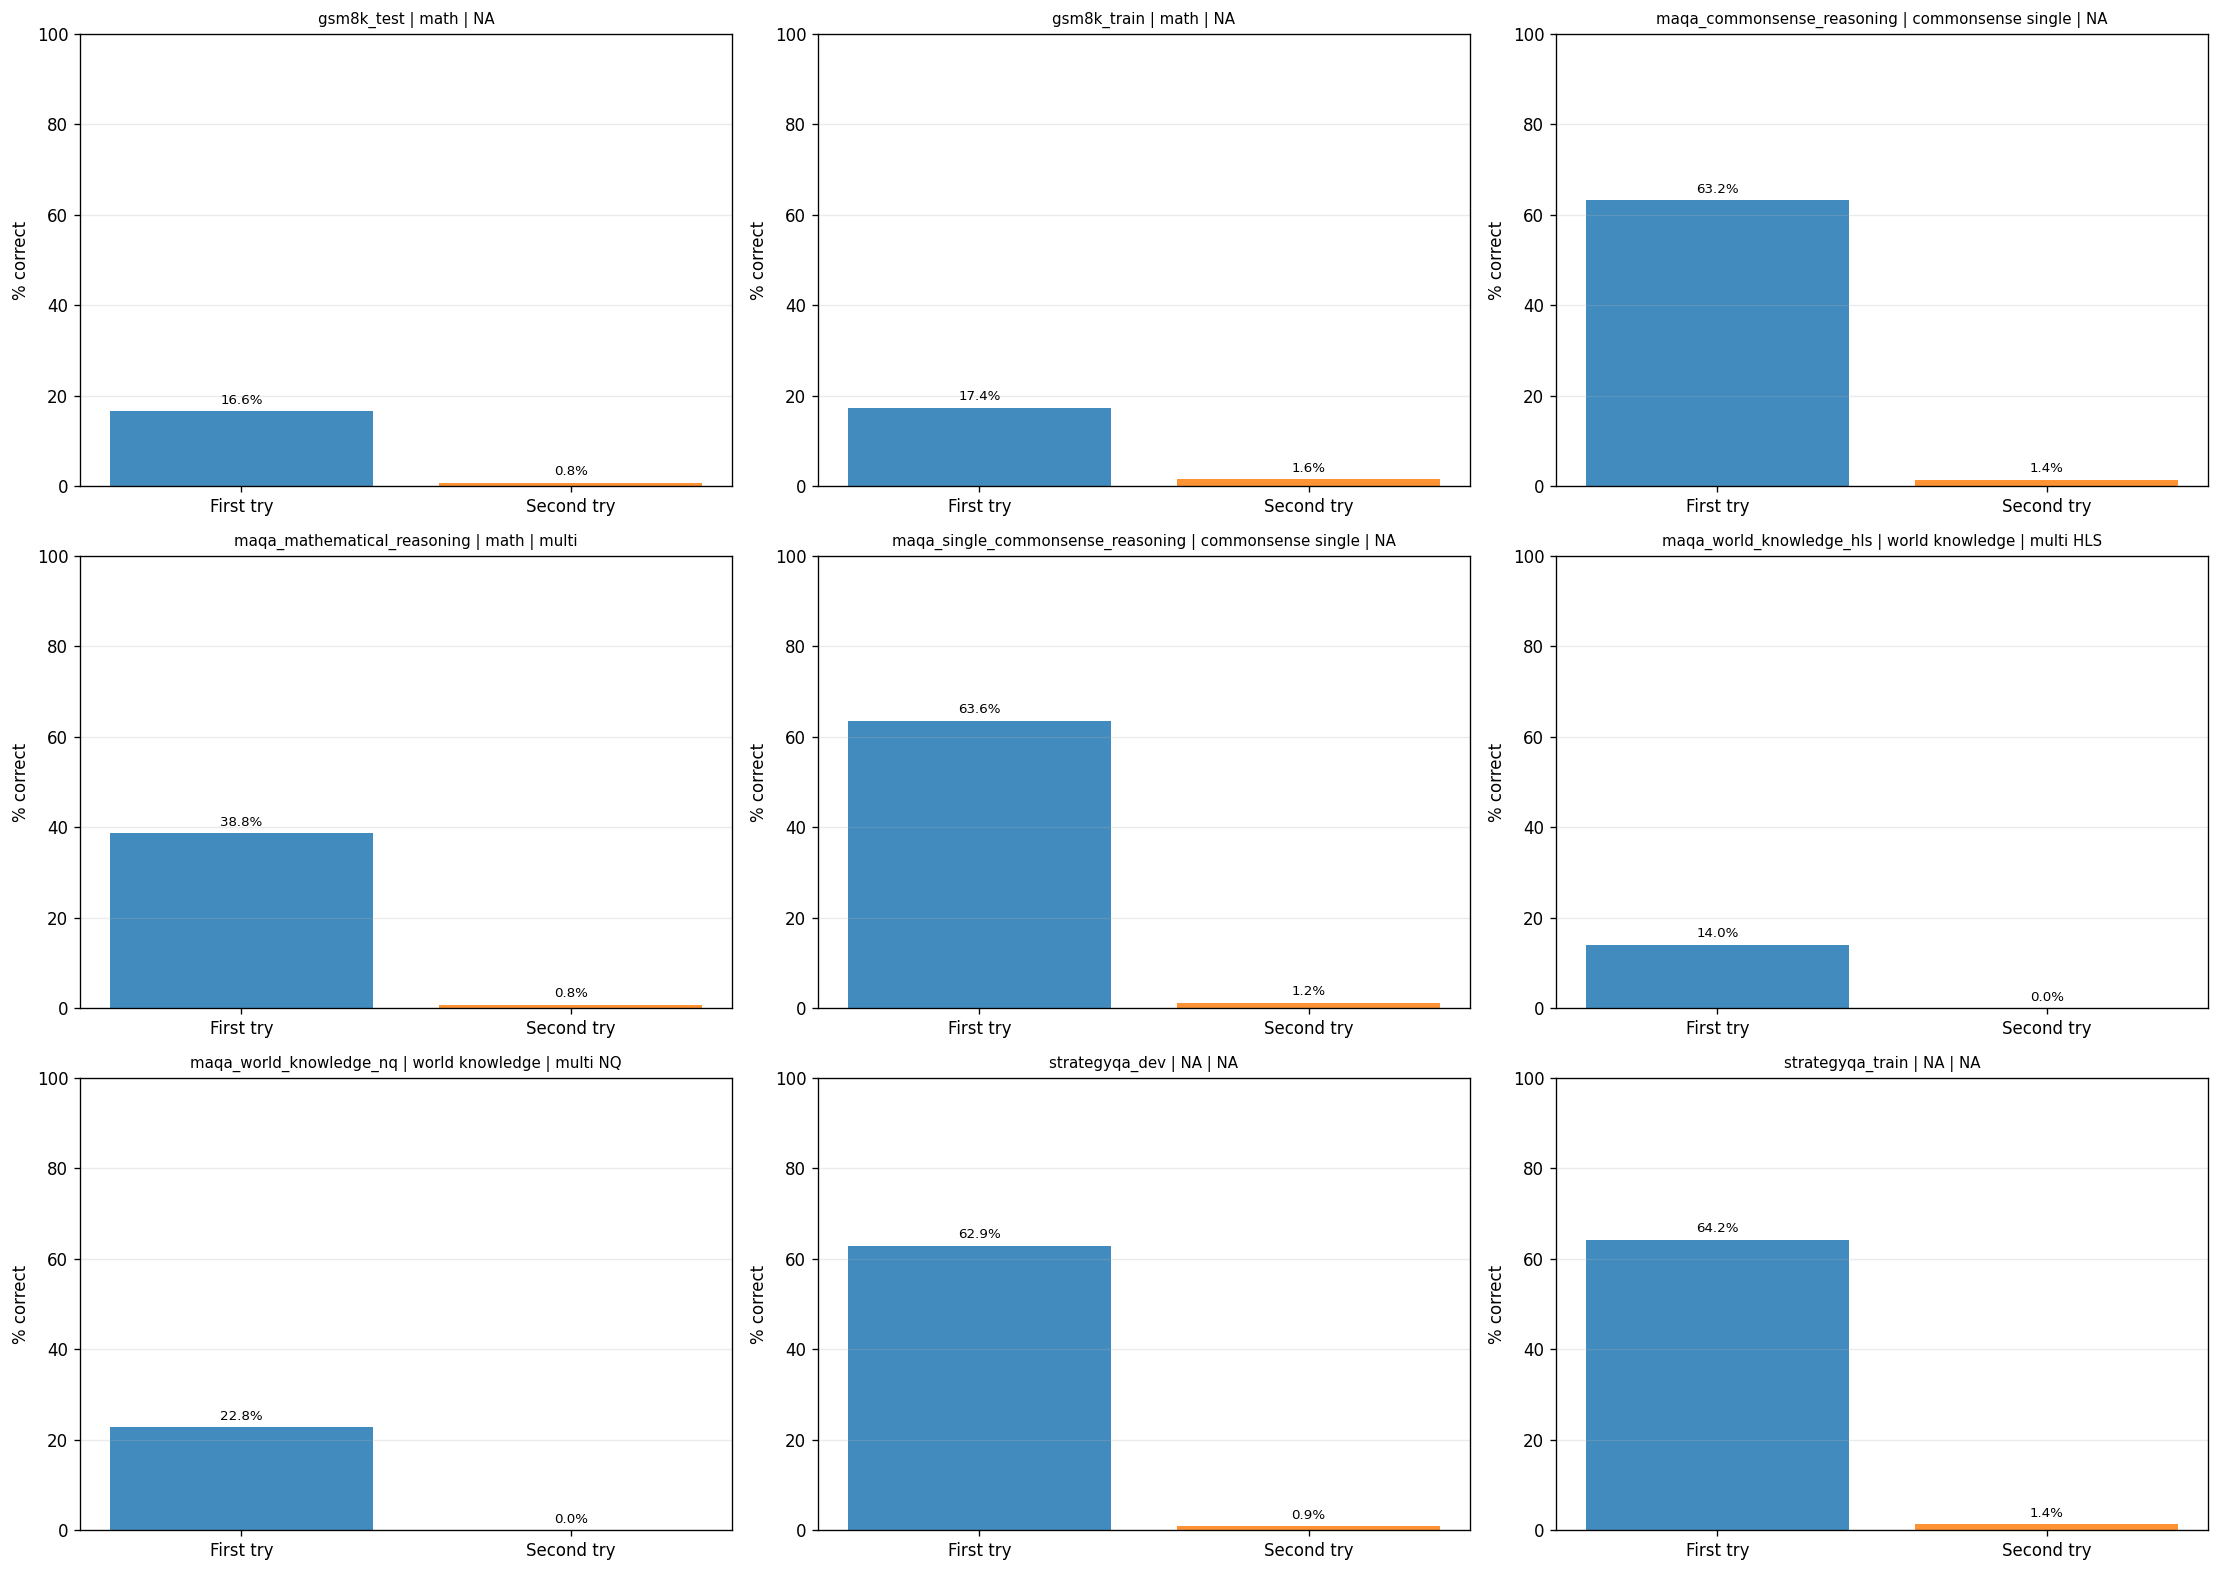

In [17]:
groups = list(iter_groups(df))
n = len(groups)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2 * ncols, 4.4 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax in axes_flat[n:]:
    ax.axis("off")

for i, ((dataset, categorie, subcategorie), g) in enumerate(groups):
    ax = axes_flat[i]
    title = f"{dataset} | {categorie} | {subcategorie}"
    ax.set_title(title, fontsize=9)

    first = g["first_try_correct"].to_numpy(dtype=int)
    second_gain = _second_try_gain(g)
    p_first = float(np.mean(first)) if first.size else 0.0
    p_second = float(np.mean(second_gain)) if second_gain.size else 0.0

    ax.bar([0, 1], [p_first * 100.0, p_second * 100.0], color=["tab:blue", "tab:orange"], alpha=0.85)
    ax.set_xticks([0, 1], ["First try", "Second try"], rotation=0)
    ax.set_ylabel("% correct")
    ax.set_ylim(0, 100)
    ax.grid(True, axis="y", alpha=0.25)
    ax.text(0, p_first * 100.0 + 1.0, f"{p_first*100.0:.1f}%", ha="center", va="bottom", fontsize=8)
    ax.text(1, p_second * 100.0 + 1.0, f"{p_second*100.0:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

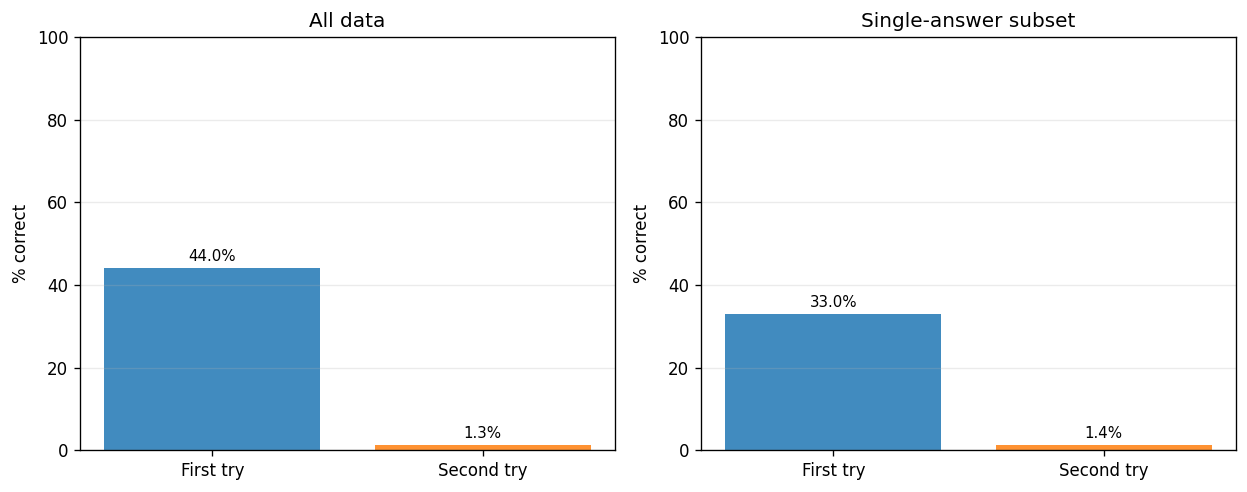

In [18]:
def plot_first_vs_second_rates(frame_all: pd.DataFrame, frame_single: pd.DataFrame) -> None:
    def _rates(frame: pd.DataFrame) -> tuple[float, float]:
        first = frame["first_try_correct"].to_numpy(dtype=int)
        second_gain = _second_try_gain(frame)
        p_first = float(np.mean(first)) if first.size else 0.0
        p_second = float(np.mean(second_gain)) if second_gain.size else 0.0
        return p_first, p_second

    p1_all, p2_all = _rates(frame_all)
    p1_s, p2_s = _rates(frame_single)

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
    for ax, (p1, p2, title) in zip(
        axes,
        [
            (p1_all, p2_all, "All data"),
            (p1_s, p2_s, "Single-answer subset"),
        ],
    ):
        ax.bar([0, 1], [p1 * 100.0, p2 * 100.0], color=["tab:blue", "tab:orange"], alpha=0.85)
        ax.set_xticks([0, 1], ["First try", "Second try"], rotation=0)
        ax.set_ylabel("% correct")
        ax.set_ylim(0, 100)
        ax.set_title(title)
        ax.grid(True, axis="y", alpha=0.25)
        ax.text(0, p1 * 100.0 + 1.0, f"{p1*100.0:.1f}%", ha="center", va="bottom", fontsize=9)
        ax.text(1, p2 * 100.0 + 1.0, f"{p2*100.0:.1f}%", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()


mask_single = (~df["dataset"].str.contains("maqa", case=False, na=False)) | (df["dataset"].str.contains("single", case=False, na=False))
df_single = df[mask_single].copy()
plot_first_vs_second_rates(df, df_single)